## Train and explain a tree model with AutoML and GeoShapleyTreeExplainer


This is a example to demostrate the newly added `GeoShapleyTreeExplainer`. This notebook mirrors the Kernel based GeoShapley AutoML example and replaces only the explainer with `GeoShapleyTreeExplainer`.

Note: `GeoShapleyTreeExplainer` is based on TreeSHAP which is mathematically different than KernelSHAP, though their results are very similar. Both are valid 

This explainer uses a different value function from
    :class:`GeoShapleyExplainer`. The Kernel explainer uses a user-supplied
    background dataset; this tree explainer uses tree path cover proportions.
    The two are often close when the background is the model training
    distribution, but they are not mathematically identical games.


In [1]:
import geopandas as gpd
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings

from sklearn.model_selection import train_test_split

In [2]:
data = pd.read_csv("https://raw.githubusercontent.com/Ziqi-Li/geoshapley/refs/heads/main/data/seattle_sample_1k.csv")

In [3]:
data = gpd.GeoDataFrame(
    data, crs="EPSG:32610", geometry=gpd.points_from_xy(x=data.UTM_X, y=data.UTM_Y))

In [4]:
y = data.log_price

X_coords = data[['bathrooms', 'sqft_living', 'sqft_lot', 'grade', 'condition',
                 'waterfront', 'view', 'age','UTM_X', 'UTM_Y']]

In [5]:
X_train, X_test, y_train, y_test = train_test_split(X_coords, y, random_state=1)

## Model training by AutoML

In [6]:
from flaml import AutoML

settings = {
    "time_budget": 20,  # total running time in seconds
    "metric": 'r2',  # primary metrics for regression can be chosen from: ['mae','mse','r2','rmse','mape']
    "estimator_list": 'auto',  # list of ML learners; 'auto' means try all
    "task": 'regression',  # task type, can also be classification   
    "eval_method": 'cv', #enable cross-validation
    "n_splits": 5, #5-fold cross validation
    "verbose": 3
}

automl = AutoML()
automl.fit(X_train, y_train,  **settings)

[flaml.automl.logger: 06-08 15:50:40] {2375} INFO - task = regression
[flaml.automl.logger: 06-08 15:50:40] {2386} INFO - Evaluation method: cv
[flaml.automl.logger: 06-08 15:50:40] {2489} INFO - Minimizing error metric: 1-r2
[flaml.automl.logger: 06-08 15:50:40] {2606} INFO - List of ML learners in AutoML Run: ['lgbm', 'rf', 'xgboost', 'extra_tree', 'xgb_limitdepth', 'sgd']
[flaml.automl.logger: 06-08 15:50:40] {2911} INFO - iteration 0, current learner lgbm
[flaml.automl.logger: 06-08 15:50:40] {3046} INFO - Estimated sufficient time budget=339s. Estimated necessary time budget=2s.
[flaml.automl.logger: 06-08 15:50:40] {3097} INFO -  at 0.0s,	estimator lgbm's best error=6.6092e-01,	best estimator lgbm's best error=6.6092e-01
[flaml.automl.logger: 06-08 15:50:40] {2911} INFO - iteration 1, current learner lgbm
[flaml.automl.logger: 06-08 15:50:40] {3097} INFO -  at 0.1s,	estimator lgbm's best error=6.6092e-01,	best estimator lgbm's best error=6.6092e-01
[flaml.automl.logger: 06-08 15:

In [7]:
auto_pred = automl.predict(X_test)

from sklearn.metrics import r2_score
r2_score(y_test, auto_pred)

0.8180801134719025

In [8]:
automl.model.estimator

LGBMRegressor(colsample_bytree=np.float64(0.5834987745562512),
              learning_rate=np.float64(0.19785013601703466), max_bin=63,
              min_child_samples=4, n_estimators=50, n_jobs=-1, num_leaves=4,
              reg_alpha=np.float64(0.0017271108100233466),
              reg_lambda=np.float64(0.003600107688175958), verbose=-1)

In [9]:
type(automl.model.estimator)

lightgbm.sklearn.LGBMRegressor

## GeoShapleyTreeExplainer

In [10]:
from geoshapley import GeoShapleyTreeExplainer

TreeGeoShapley does not require a background sample. It uses the fitted tree ensemble path cover proportions, analogous to TreeSHAP's tree-path-dependent value function.


In [11]:
%%time
automl_explainer = GeoShapleyTreeExplainer(automl.model.estimator, g=2)

rslt = automl_explainer.explain(X_coords)


CPU times: user 2.1 s, sys: 16.9 ms, total: 2.11 s
Wall time: 2.11 s


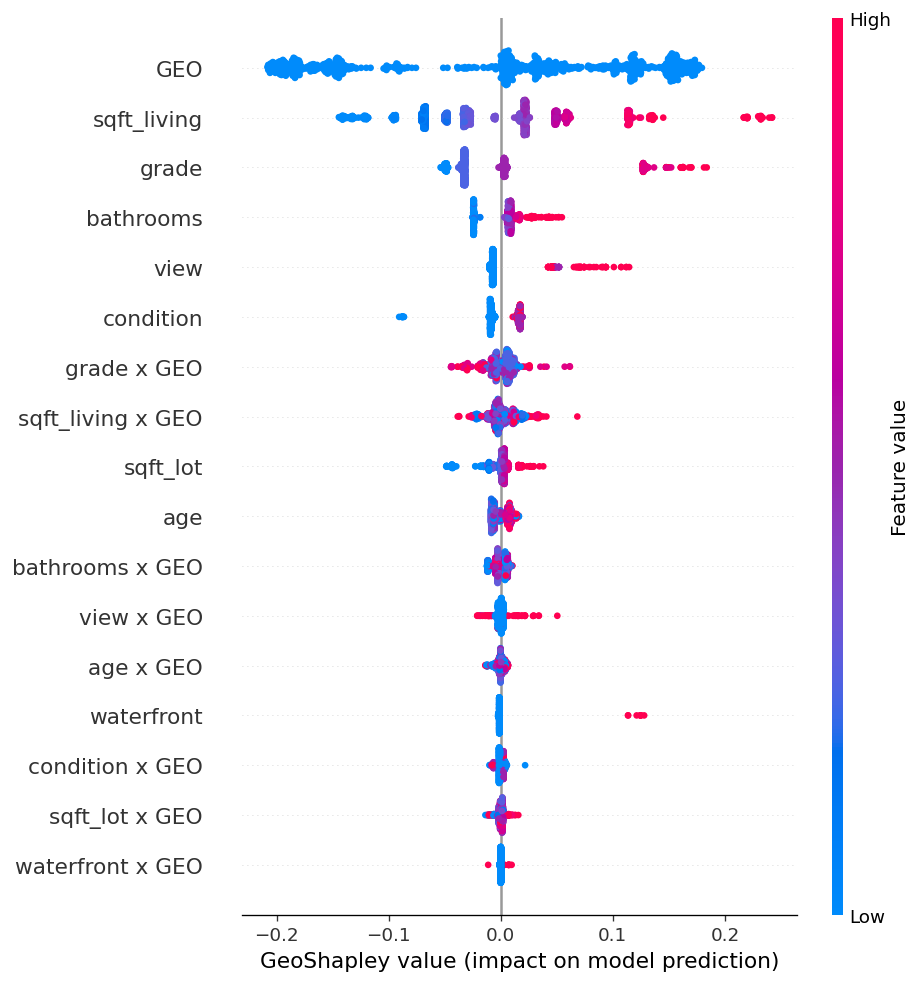

In [12]:
rslt.summary_plot(dpi=120)

In [13]:
rslt.summary_statistics()

,min,25%,50%,75%,max,mean,std,abs. mean
GEO,-0.208154,-0.143789,0.023309,0.118745,0.179518,0.002748,0.127345,0.109114
sqft_living,-0.144391,-0.049906,-0.004742,0.048224,0.242040,0.000087,0.078397,0.062602
grade,-0.053646,-0.033235,-0.031966,0.002942,0.183804,0.000197,0.059687,0.042585
bathrooms,-0.025094,-0.023874,0.007144,0.008841,0.054603,0.000993,0.016982,0.014489
view,-0.009752,-0.007282,-0.007001,-0.006844,0.114594,-0.000822,0.021045,0.012418
condition,-0.090592,-0.009299,-0.008265,0.015908,0.019268,0.000047,0.015061,0.012404
grade x GEO,-0.044390,-0.005992,0.003627,0.007537,0.061734,0.000088,0.011844,0.009003
sqft_living x GEO,-0.038373,-0.004559,-0.000727,0.005939,0.068354,0.001159,0.011734,0.008376
sqft_lot,-0.048307,0.000089,0.001293,0.003286,0.037979,-0.000195,0.011368,0.006430
age,-0.008711,-0.006643,-0.001680,0.006767,0.016295,-0.000158,0.007073,0.006372


In [14]:
rslt.check_additivity()

Components add up to model prediction:  True


### Location invariant primary effects

100% (10 of 10) |########################| Elapsed Time: 0:00:00 Time:  0:00:00
100% (10 of 10) |########################| Elapsed Time: 0:00:00 Time:  0:00:000:00
100% (10 of 10) |########################| Elapsed Time: 0:00:00 Time:  0:00:00
100% (10 of 10) |########################| Elapsed Time: 0:00:00 Time:  0:00:00
100% (10 of 10) |########################| Elapsed Time: 0:00:00 Time:  0:00:00
100% (10 of 10) |########################| Elapsed Time: 0:00:00 Time:  0:00:00
100% (10 of 10) |########################| Elapsed Time: 0:00:00 Time:  0:00:00
100% (10 of 10) |########################| Elapsed Time: 0:00:00 Time:  0:00:00


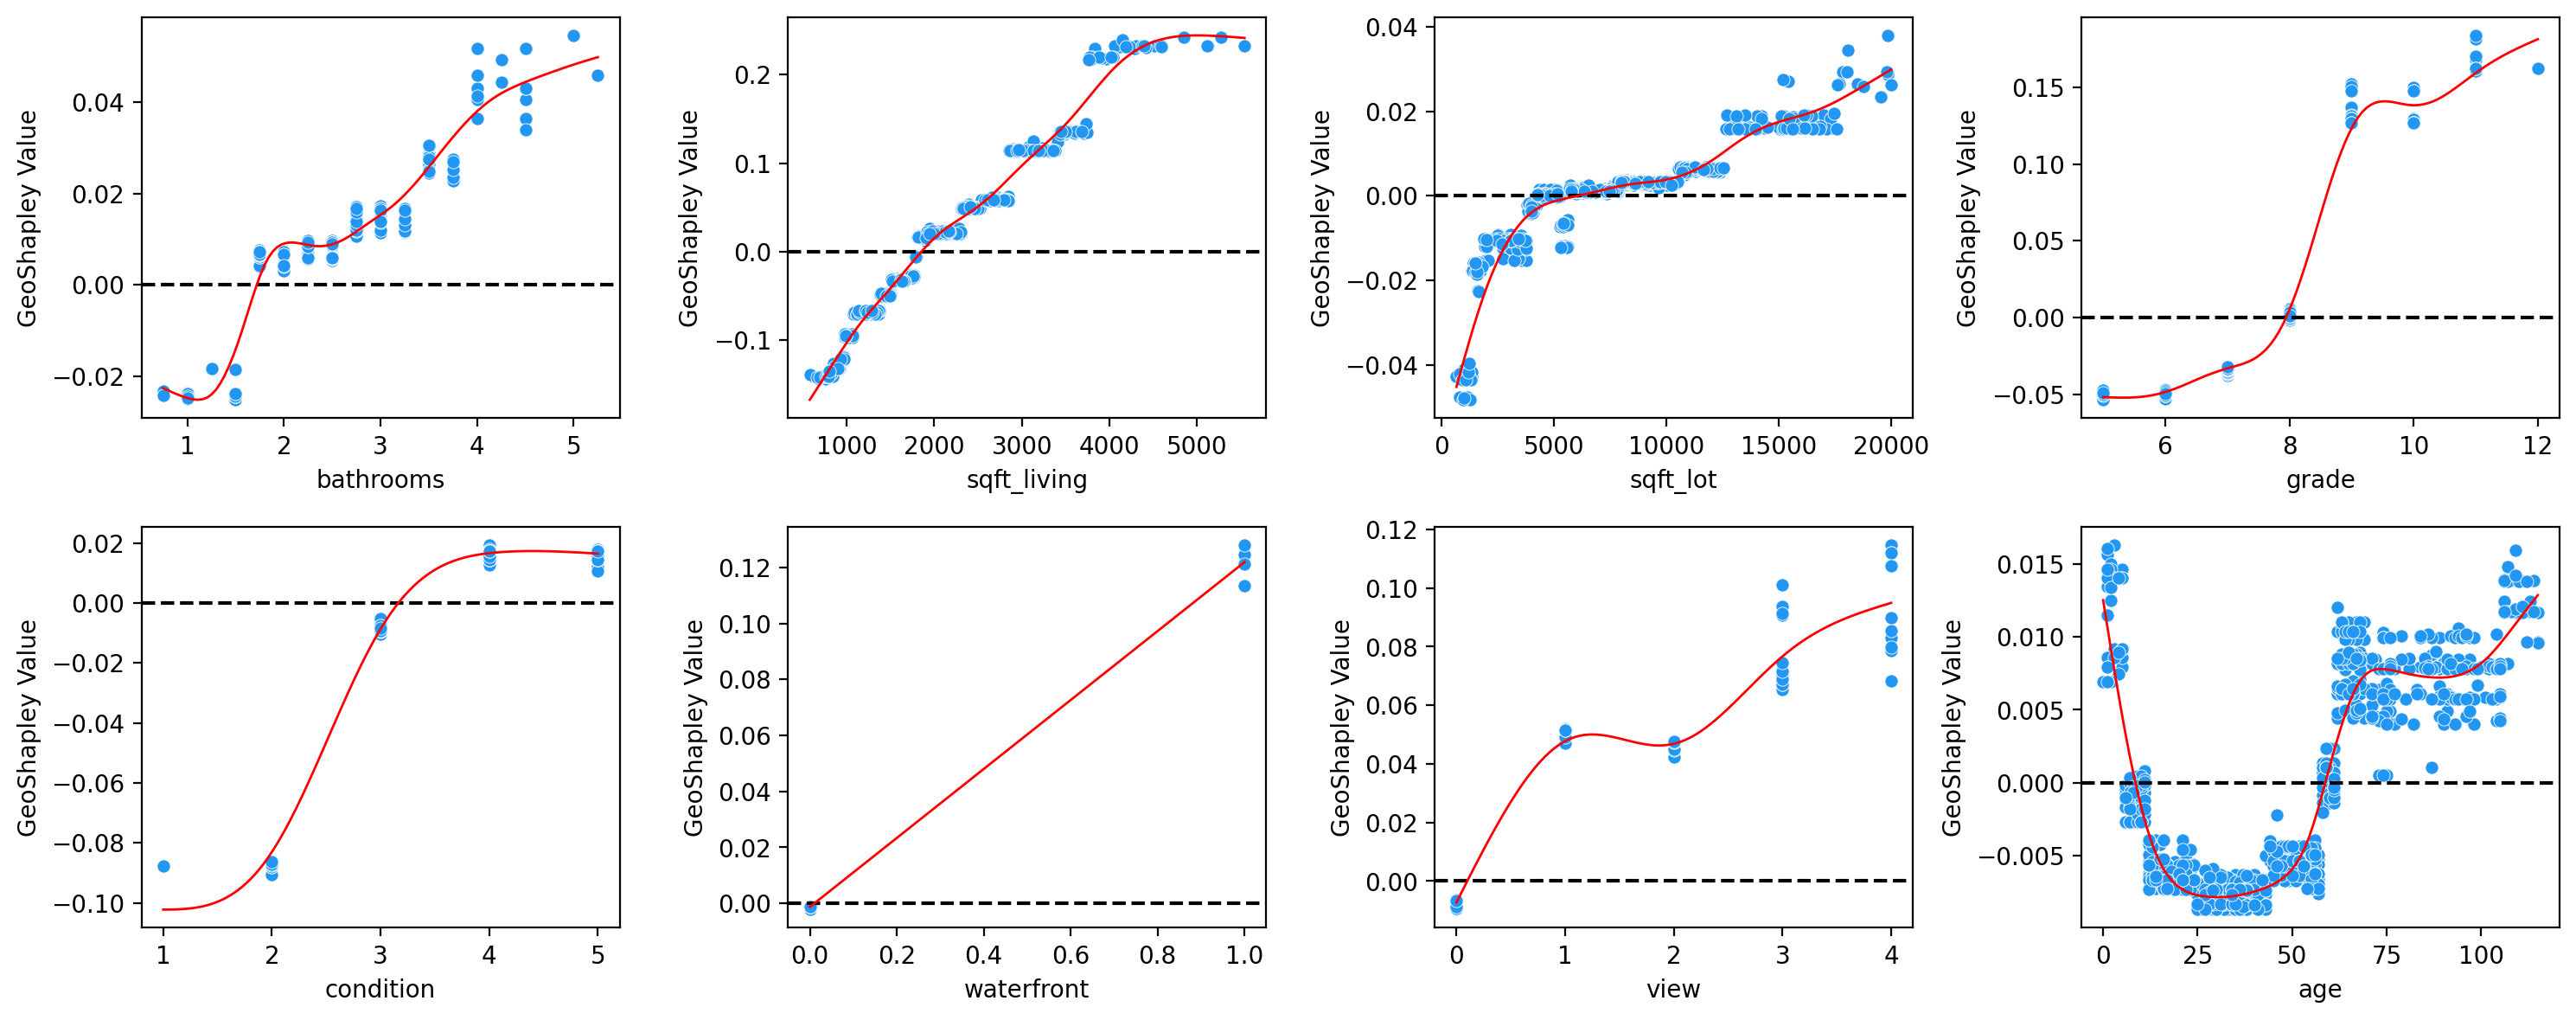

In [15]:
rslt.partial_dependence_plots(figsize=(15,6),max_cols=4,gam_curve=True,s=30)

In [16]:
coords = data[['UTM_X','UTM_Y']].values

## Calculate Spatially Varying Coefficients from GeoShapley values

SVCs are smoothed using GWR.

In [17]:
#if include_primary is set to True, the spatially varying effects will contain the above non-linear effects.
svc = rslt.get_svc(col = [0,1,2,3,4,5,6,7], coef_type="gwr", include_primary=False, coords=coords)

In [18]:
X_coords.columns

Index(['bathrooms', 'sqft_living', 'sqft_lot', 'grade', 'condition',
       'waterfront', 'view', 'age', 'UTM_X', 'UTM_Y'],
      dtype='object')

In [19]:
import contextily as cx

### Intrinsic location effect

<Axes: >

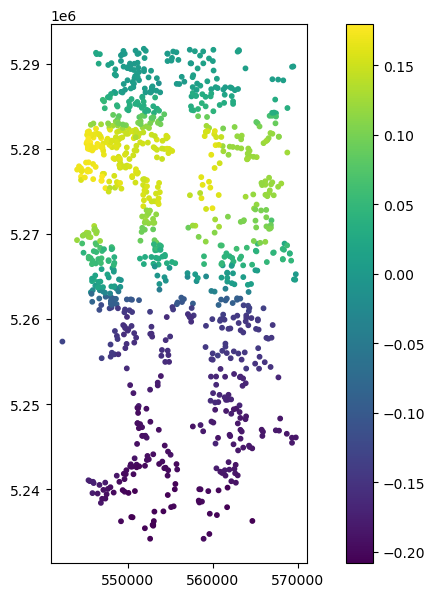

In [21]:
fig, ax = plt.subplots(1, 1,figsize=(10,7),dpi=100)

data.plot(ax=ax,column=rslt.geo,
                  s=10,figsize=(10,10),legend=True)


### Spatially varying coefficient for sqft_living (after removing global primary effect)

<Axes: >

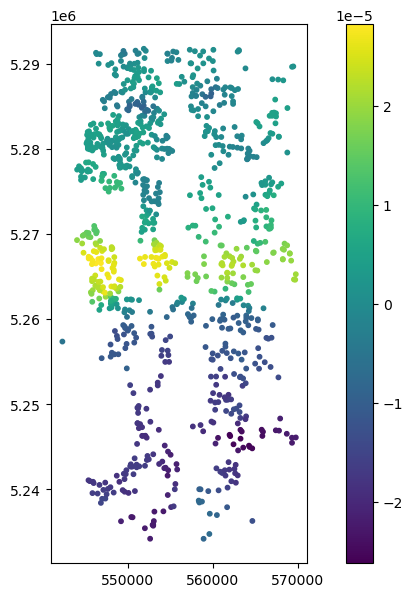

In [22]:
fig, ax = plt.subplots(1, 1,figsize=(10,7),dpi=100)

data.plot(ax=ax,column=svc[:,1],
                  s=10,figsize=(10,10),legend=True)


### Spatially varying coefficient for age (after removing global primary effect)

<Axes: >

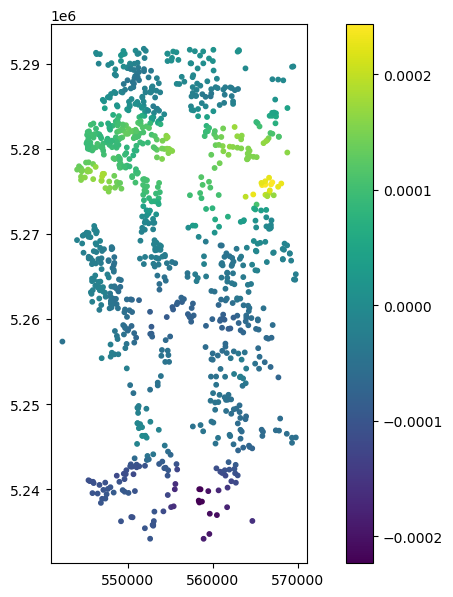

In [23]:
fig, ax = plt.subplots(1, 1,figsize=(10,7),dpi=100)

data.plot(ax=ax,column=svc[:,7],
                  s=10,figsize=(10,10),legend=True)


### Spatially varying coefficient for waterfront (after removing global primary effect)

<Axes: >

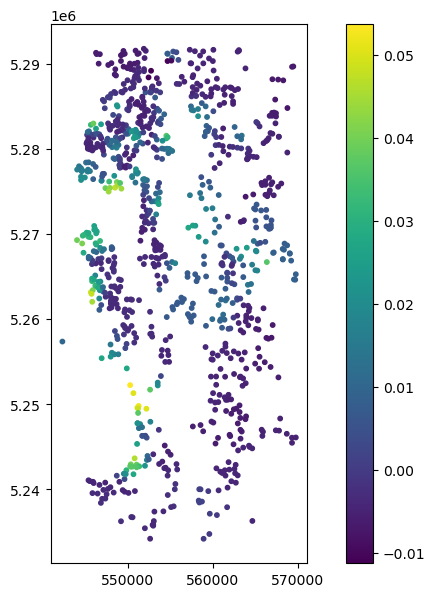

In [24]:
fig, ax = plt.subplots(1, 1,figsize=(10,7),dpi=100)

data.plot(ax=ax,column=svc[:,5],
                  s=10,figsize=(10,10),legend=True)
